In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_theme(style="whitegrid")

In [2]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
perf_df = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

print(nav_df.shape)
print(perf_df.shape)

(46000, 3)
(40, 19)


In [3]:
nav_df = nav_df.sort_values(
    ["amfi_code","date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

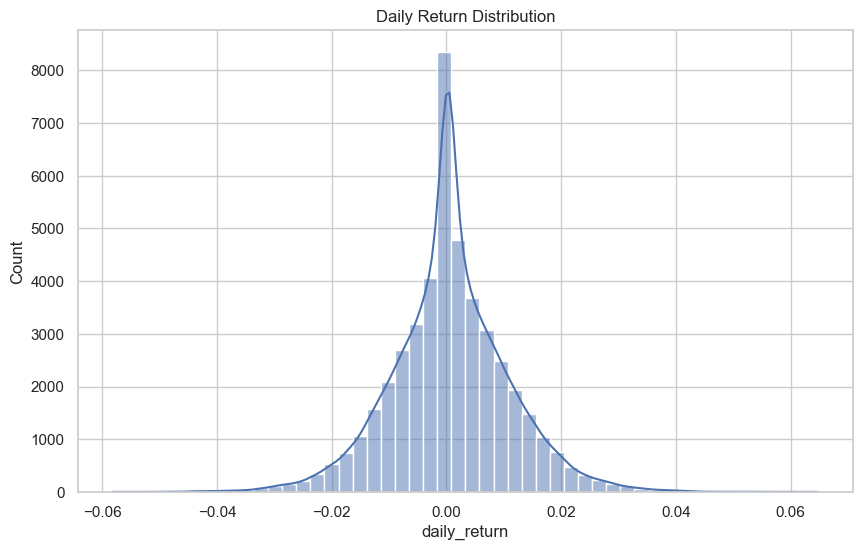

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")
plt.show()

In [6]:
cagr_list = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ].sort_values("date")

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        (temp["date"].max() -
         temp["date"].min()).days
        /365
    )

    cagr = (
        (end_nav/start_nav)**(1/years)-1
    )

    cagr_list.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code","cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
rf = 0.065

sharpe_list = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ]

    mean_return = (
        temp["daily_return"]
        .mean()*252
    )

    std_return = (
        temp["daily_return"]
        .std()*np.sqrt(252)
    )

    sharpe = (
        mean_return-rf
    )/std_return

    sharpe_list.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [8]:
rf = 0.065

sortino_list = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    downside = returns[returns < 0]

    annual_return = returns.mean()*252

    downside_std = (
        downside.std()*np.sqrt(252)
    )

    sortino = (
        annual_return-rf
    )/downside_std

    sortino_list.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [9]:
mdd_list = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"] /
        temp["running_max"]
    ) - 1

    max_dd = temp["drawdown"].min()

    mdd_list.append(
        [fund,max_dd]
    )

mdd_df = pd.DataFrame(
    mdd_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [10]:
benchmark = (
    nav_df.groupby("date")
    ["daily_return"]
    .mean()
    .reset_index()
)

alpha_beta = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        temp,
        benchmark,
        on="date",
        suffixes=(
            "_fund",
            "_benchmark"
        )
    ).dropna()

    slope, intercept, r, p, stderr = linregress(
        merged["daily_return_benchmark"],
        merged["daily_return_fund"]
    )

    beta = slope
    alpha = intercept * 252

    alpha_beta.append(
        [fund,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


In [11]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    sortino_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    mdd_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta
0,100016,0.026352,-0.201517,-0.351047,-0.247344,-0.089699,0.788441
1,100025,0.044551,-0.567095,-0.941821,-0.043083,0.033199,0.060713
2,100033,0.300997,1.093699,1.829134,-0.162172,0.114423,0.991590
3,101206,0.235205,1.027213,1.799563,-0.112916,0.097443,0.737015
4,101207,0.079331,0.162661,0.276644,-0.354469,-0.350741,2.878184


In [12]:
scorecard["rank_cagr"] = (
    scorecard["cagr"]
    .rank(pct=True)
)

scorecard["rank_sharpe"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["rank_alpha"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["rank_mdd"] = (
    scorecard["max_drawdown"]
    .rank(
        pct=True,
        ascending=False
    )
)

scorecard["score"] = (
      scorecard["rank_cagr"]*30
    + scorecard["rank_sharpe"]*25
    + scorecard["rank_alpha"]*20
    + scorecard["rank_mdd"]*25
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,rank_cagr,rank_sharpe,rank_alpha,rank_mdd,score
0,100016,0.026352,-0.201517,-0.351047,-0.247344,-0.089699,0.788441,0.100,0.150,0.225,0.850,32.500
1,100025,0.044551,-0.567095,-0.941821,-0.043083,0.033199,0.060713,0.125,0.050,0.475,0.100,17.000
2,100033,0.300997,1.093699,1.829134,-0.162172,0.114423,0.991590,0.850,0.850,0.925,0.500,77.750
3,101206,0.235205,1.027213,1.799563,-0.112916,0.097443,0.737015,0.725,0.800,0.850,0.225,64.375
4,101207,0.079331,0.162661,0.276644,-0.354469,-0.350741,2.878184,0.350,0.325,0.025,0.950,42.875


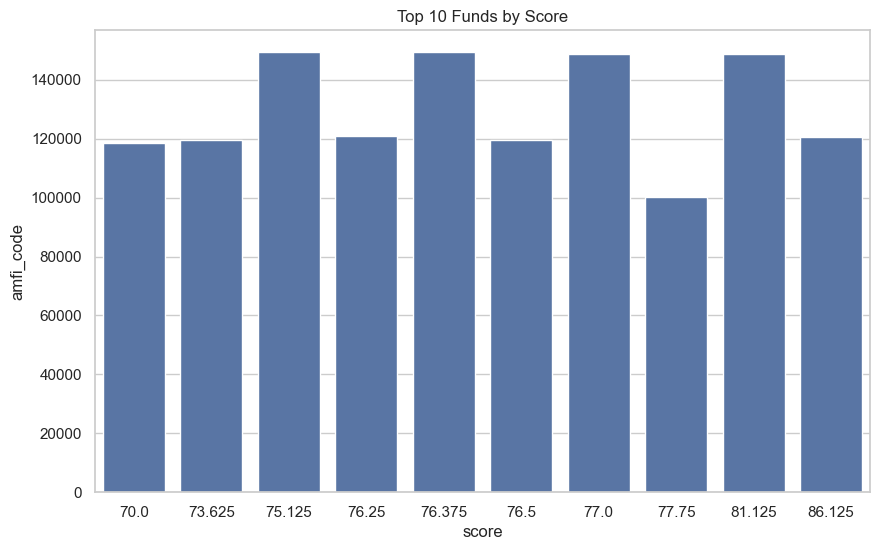

In [13]:
top_funds = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_funds,
    x="score",
    y="amfi_code"
)

plt.title(
    "Top 10 Funds by Score"
)

plt.show()

In [14]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Files saved.")

Files saved.
